### Evaluate and Plot Resutls

In [1]:
# Imports
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib as mpl
import sci_mplstyle_package


if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
model_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "src"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
sys.path.append(model_dir)
from data_processing import load_cluster
from yaml_processor import load_config, save_config
from sensor_processing import sensor_processing

from EDM import EDM

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

Duplicate key in file 'c:\\Users\\haida\\anaconda3\\envs\\neuromancer\\lib\\site-packages\\sci_mplstyle_package\\style_files\\publication.mplstyle', line 64 ('axes.axisbelow : True')


In [2]:
# Parameters
cluster = 0
chkpnt_path = os.path.join(output_dir, "model_checkpoint", str(cluster))
nx = config_global["data"]["nx"]
nt = config_global["data"]["nt"]
T = 1/np.pi
t = np.linspace(0, T, nt)
dt = t[1]-t[0]

In [3]:
# Set device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load Data
FS_train, params_train, ft_train, disp_norm, vel_norm, ft_norm = load_cluster(os.path.join(output_dir, "datasets", "Train"), cluster, normalize=True)
FS_val, params_val, ft_val, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Val"), cluster, True, disp_norm, vel_norm, ft_norm)
FS_test, params_test, ft_test, _, _, _ = load_cluster(os.path.join(output_dir, "datasets", "Test"), cluster, True, disp_norm, vel_norm, ft_norm)

In [4]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

# Reshape
n_dim = RS_train.shape[1]
RS_train = np.concatenate([RS_train[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_val = np.concatenate([RS_val[:, i, :, :] for i in range(n_dim)], axis=-1)
RS_test = np.concatenate([RS_test[:, i, :, :] for i in range(n_dim)], axis=-1)

model = EDM(A_Mat, pinv_Theta, dt, config_global, device)
model.build_model(gate_config="narrow", method="lora_lpv_resid")

# Load model
model_params = os.path.abspath(os.path.join(output_dir, "model_checkpoint", str(cluster))) + "/best_model_state_dict.pth"
model.problem.load_state_dict(torch.load(model_params, map_location=torch.device(device)))

In [5]:
model = EDM(A_Mat, pinv_Theta, dt, config_global, device)


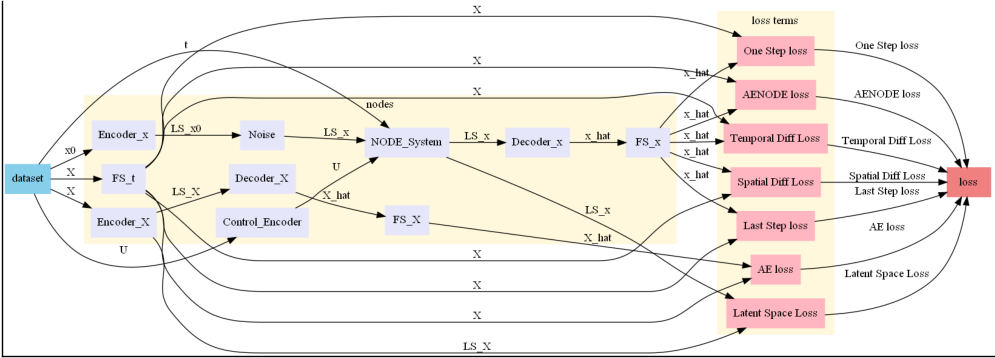

In [6]:
# "rbf_lpv_resid" worked best so far
model.build_model(gate_config="narrow", method="ssm", indx_q=1)

In [7]:
model_params = os.path.join(chkpnt_path, "best_model_state_dict.pth")
state = torch.load(model_params, map_location=torch.device(device))
model.problem.load_state_dict(state)

<All keys matched successfully>

In [8]:
model.problem.nodes[4].nsteps = nt
model.problem.eval()

### MODEL SUMMARY ###

NODES:
  Encoder_x(x0) -> LS_x0
  Encoder_X(X) -> LS_X
  Noise(LS_x0) -> LS_x
  Control_Encoder(U) -> U
  System(
  (nodes): ModuleList(
    (0): NODE(LS_x, U, t) -> LS_x
  )
)
  Decoder_x(LS_x) -> x_hat
  Decoder_X(LS_X) -> X_hat
  FS_x(x_hat) -> x_hat
  FS_X(X_hat) -> X_hat
  FS_t(X) -> X

CONSTRAINTS: none

OBJECTIVES:
  Constraint(
  (left): slice
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): X_hat
  (right): X
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): slice
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): LS_X
  (right): slice
  (comparator): Eq()
)
  Constraint(
  (left): -
  (right): -
  (comparator): Eq()
)
  Constraint(
  (left): +
  (right): +
  (comparator): Eq()
)

In [9]:
_, _, test_data = model.get_data(RS_train, ft_train, RS_val, ft_val, RS_test, ft_test, t[:, np.newaxis])
outputs = model.problem.step(test_data)

In [9]:
t_max = 1/torch.pi
t_torch = torch.tensor(t[:, np.newaxis])
centers = torch.tensor([0.35, 0.5, 0.65]).to(device)
#centers += t_max
t_norm = (t_torch / t_max).clamp(0.0, 1.0).to(device)
diff    = (t_norm - centers).abs()
weights = torch.softmax(- (diff**2) / (2 * 0.02**2), dim=1)

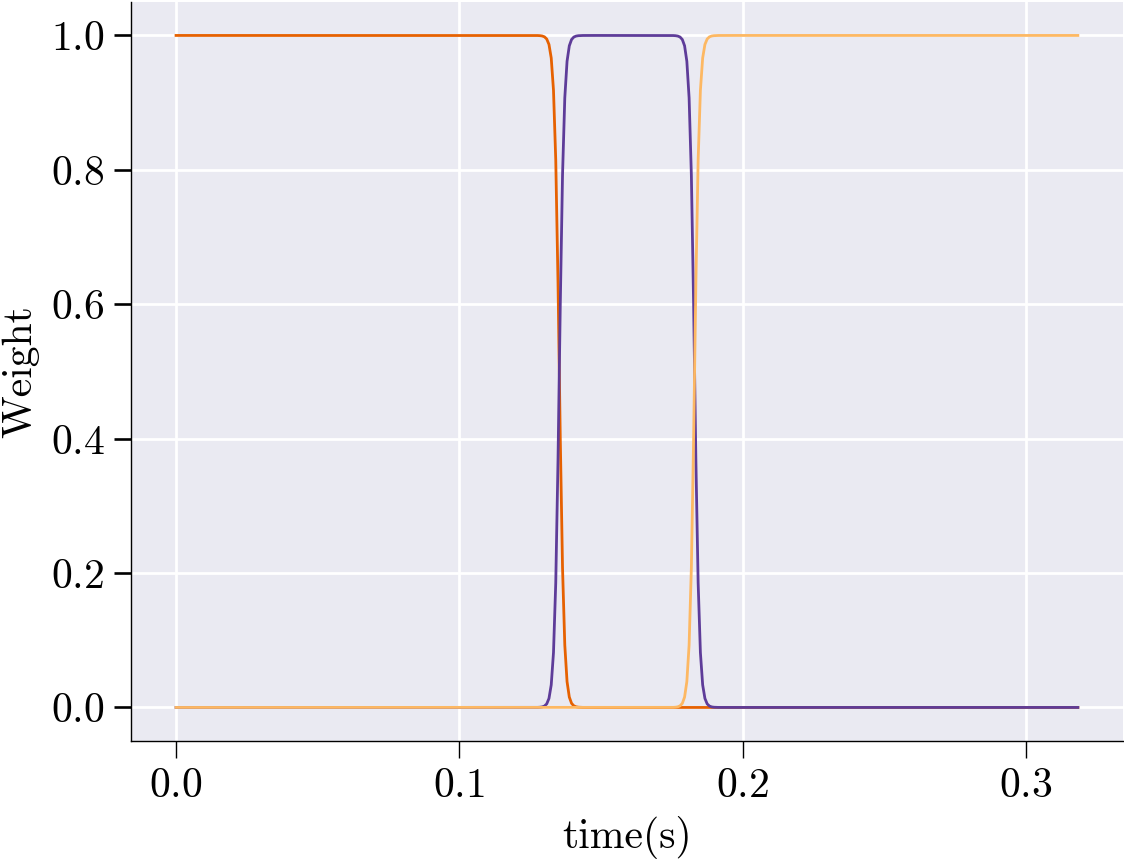

In [10]:
plt.figure(dpi=200)
plt.plot(t, weights.cpu().detach().numpy())
plt.xlabel("time(s)")
plt.ylabel("Weight")
plt.show()

In [10]:
FS_reshaped = FS_test.transpose(0, 2, 1, 3).reshape(128, 400, 202)
FS_LS = outputs['LS_X'].cpu().detach().numpy()
FS_AE = outputs['X_hat'][:, :, :].cpu().detach().numpy()
FS_pred = outputs['x_hat'][:, :-1, :].cpu().detach().numpy()

In [11]:
print(f"Frob norm for AE is : {np.linalg.norm(FS_AE-FS_reshaped)/np.linalg.norm(FS_reshaped)}")
print(f"Frob norm for NODE is : {np.linalg.norm(FS_pred-FS_reshaped)/np.linalg.norm(FS_reshaped)}")

Frob norm for AE is : 0.15285663624222554
Frob norm for NODE is : 28512649.844039656


In [12]:
print(f"Frob norm for AE-NODE Difference is : {np.linalg.norm(FS_pred-FS_AE)/np.linalg.norm(FS_AE)}")

Frob norm for AE-NODE Difference is : 29318048.0


In [13]:
errs = np.zeros((FS_reshaped.shape[0],))

In [14]:
for i in range(FS_reshaped.shape[0]):
    errs[i] = np.linalg.norm(FS_pred[i]-FS_reshaped[i])/np.linalg.norm(FS_reshaped[i])

C:\Users\haida\AppData\Local\Temp\ipykernel_14684\2309396687.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


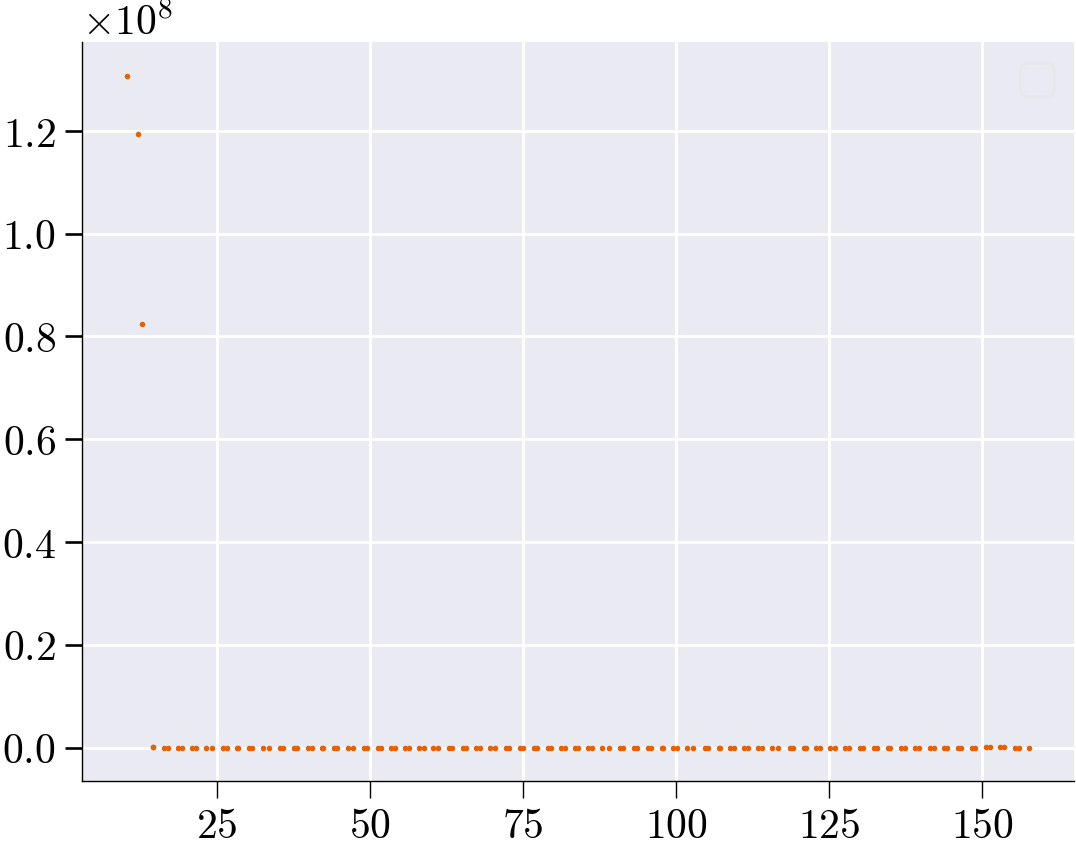

In [15]:
plt.figure()
plt.scatter(params_test, errs, marker='o')
plt.legend()
plt.show()

In [16]:
time_test = np.linspace(0, 1/np.pi, 100)

In [ ]:
time_test = time_test[:, np.newaxis]

In [ ]:
time_test = torch.tensor(time_test).to(device)
gating = model.problem.nodes[4].nodes[0].callable.block._time_weights(time_test)

In [ ]:
gating = gating.detach().cpu().numpy()

In [ ]:
plt.figure()
plt.plot(gating[:, 0])
plt.plot(gating[:, 1])
plt.plot(gating[:, 2])
plt.show()

## Params and Sensors

In [ ]:
# Params scatter
plt.figure(dpi=200)
plt.tight_layout()
plt.vlines(params_train[:, 0], ymin=-1, ymax=1, colors="#e66101", label="Training")
plt.vlines(params_val[:, 0], ymin=-1, ymax=1, colors="#5e3c99", label="Validation")
plt.vlines(params_test[:, 0], ymin=-1, ymax=1, colors="#fdb863", alpha = 0.35, label="Testing")
plt.yticks([])
ax = plt.gca()
ax.spines['left'].set_visible(False)
plt.xlabel(r"$\omega$")
plt.legend(loc="upper right")
plt.show()

In [ ]:
# Sensor Locations
beam = mpimg.imread("supplementary/beam.jpg")
height, width = beam.shape[:2]
xbounds = np.array([72, 545])
xs = (sensor_placement/100)*(xbounds[1]-xbounds[0])+xbounds[0]
ys = np.array([3]*len(sensor_placement))
plt.imshow(beam)
plt.scatter(xs, ys, c='red', s=10, marker='o')  # Customize as needed
plt.axis('off')

x0, y0 = xbounds[0], 120
x_axis_len = xbounds[1]-xbounds[0]
plt.annotate('', xy=(x0 + x_axis_len, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='->', color='black', linewidth=1.2))
xticks = np.linspace(0, 100, 5)
for val in xticks:
    x_tick_pos = x0 + val / 100 * x_axis_len
    plt.plot([x_tick_pos, x_tick_pos], [y0 - 5, y0 + 5], color='black', linewidth=1)
    plt.text(x_tick_pos, y0 + 10, f'{float(val/100)}', ha='center', va='top', fontsize=8)
plt.ylim(height+10, -10)
plt.show()

## Results Plots

### Latent Space

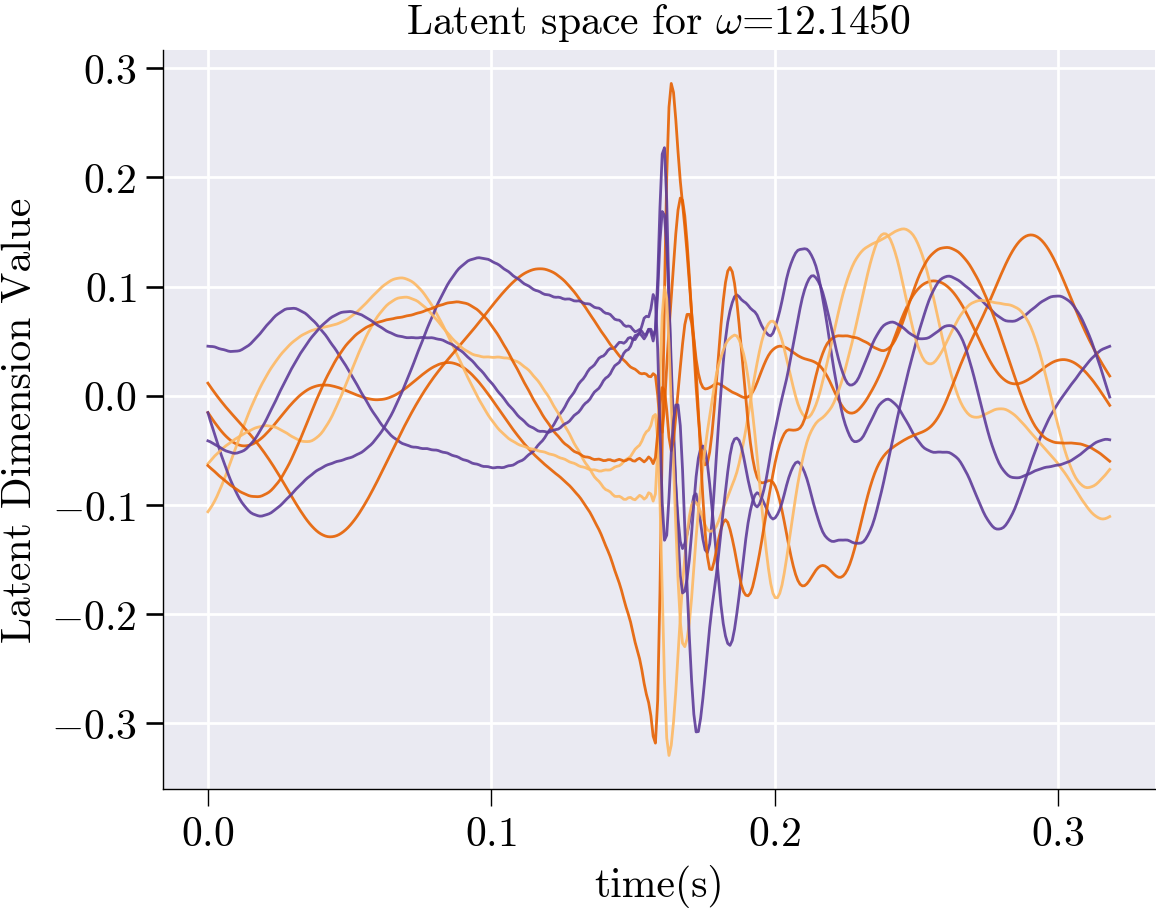

In [16]:
## Latent Spaces
p=4
plt.figure(dpi=200)
plt.plot(t, FS_LS[p, :], alpha=0.9)
plt.xlabel("time(s)")
plt.ylabel("Latent Dimension Value")
plt.title(fr"Latent space for $\omega$={params_test[p,0]:.4f}")
plt.show()

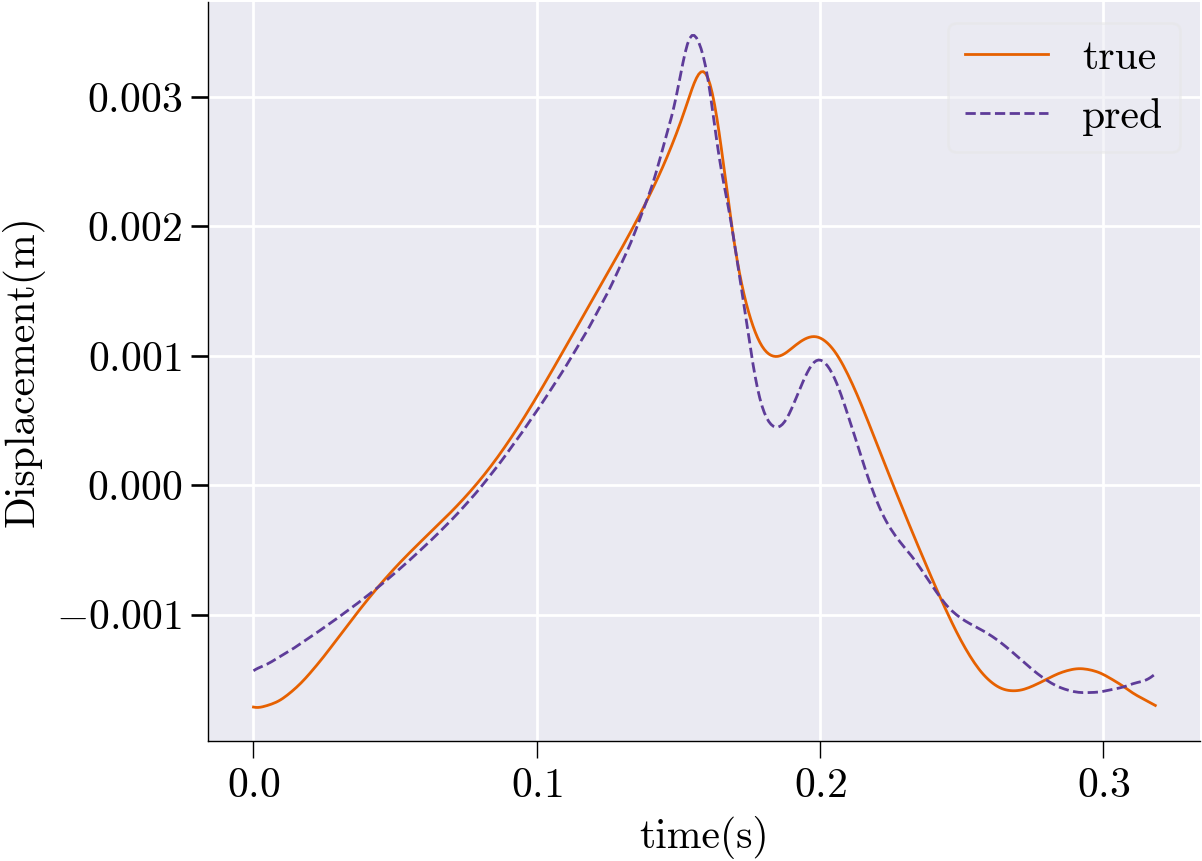

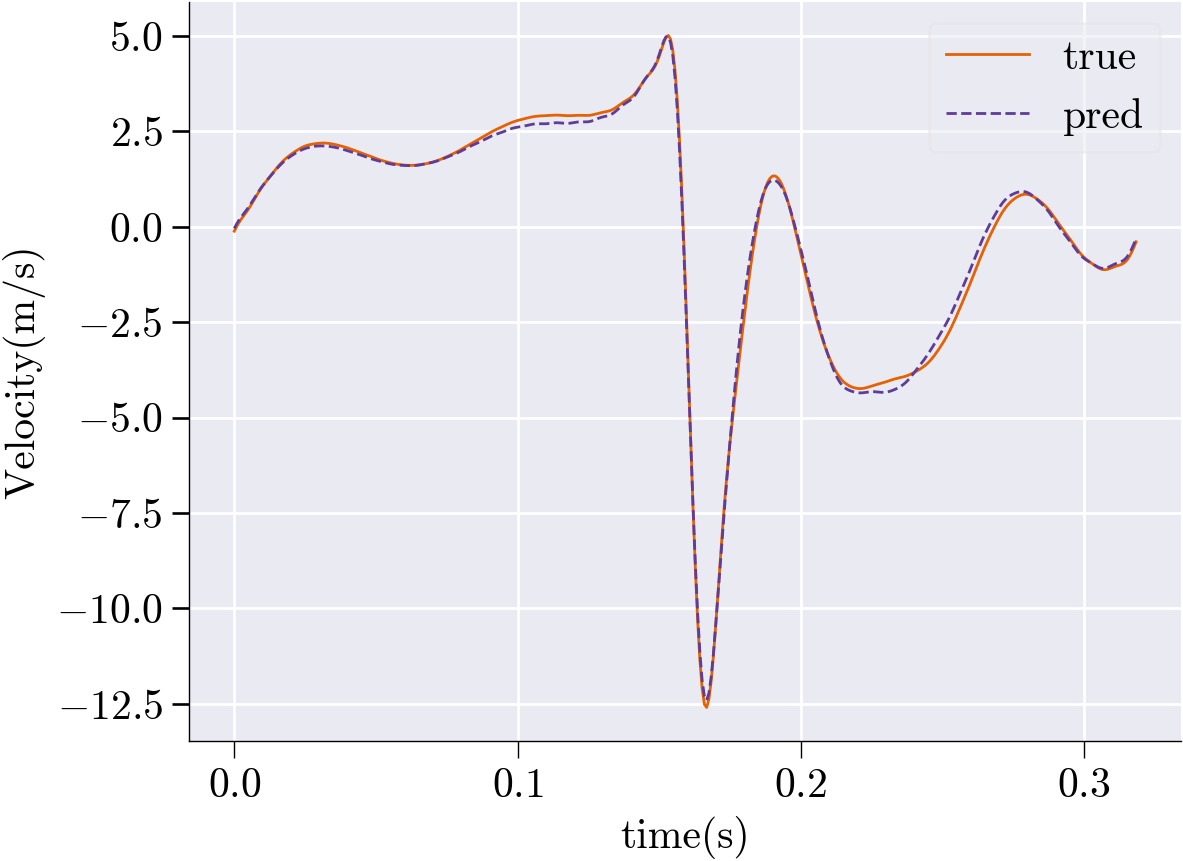

In [17]:
p = 0
x = 75
# Displacement
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x]*disp_norm, label="true")
plt.plot(t, FS_AE[p, :, x]*disp_norm, '--', label="pred")

plt.ylabel("Displacement(m)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

# Velocity
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x+nx]*vel_norm, label="true")
plt.plot(t, FS_AE[p, :, x+nx]*vel_norm, '--', label="pred")

plt.ylabel("Velocity(m/s)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

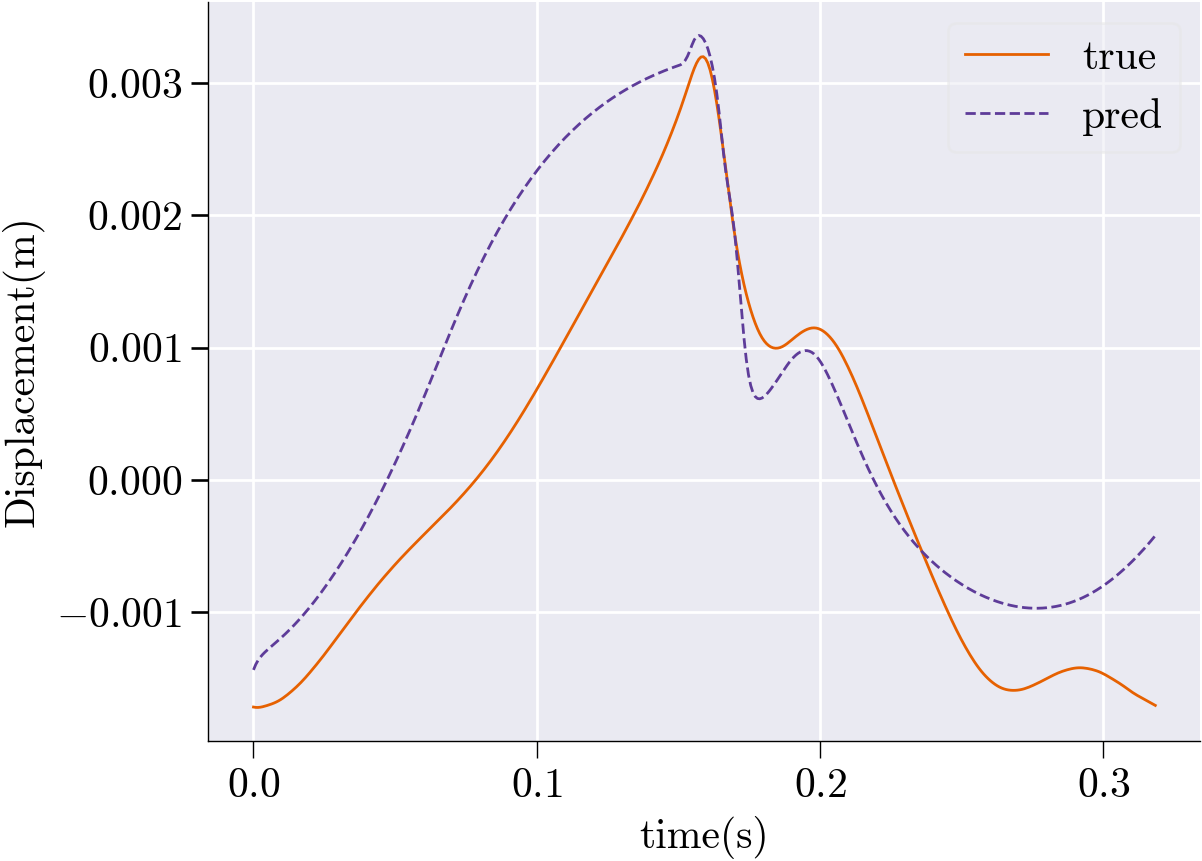

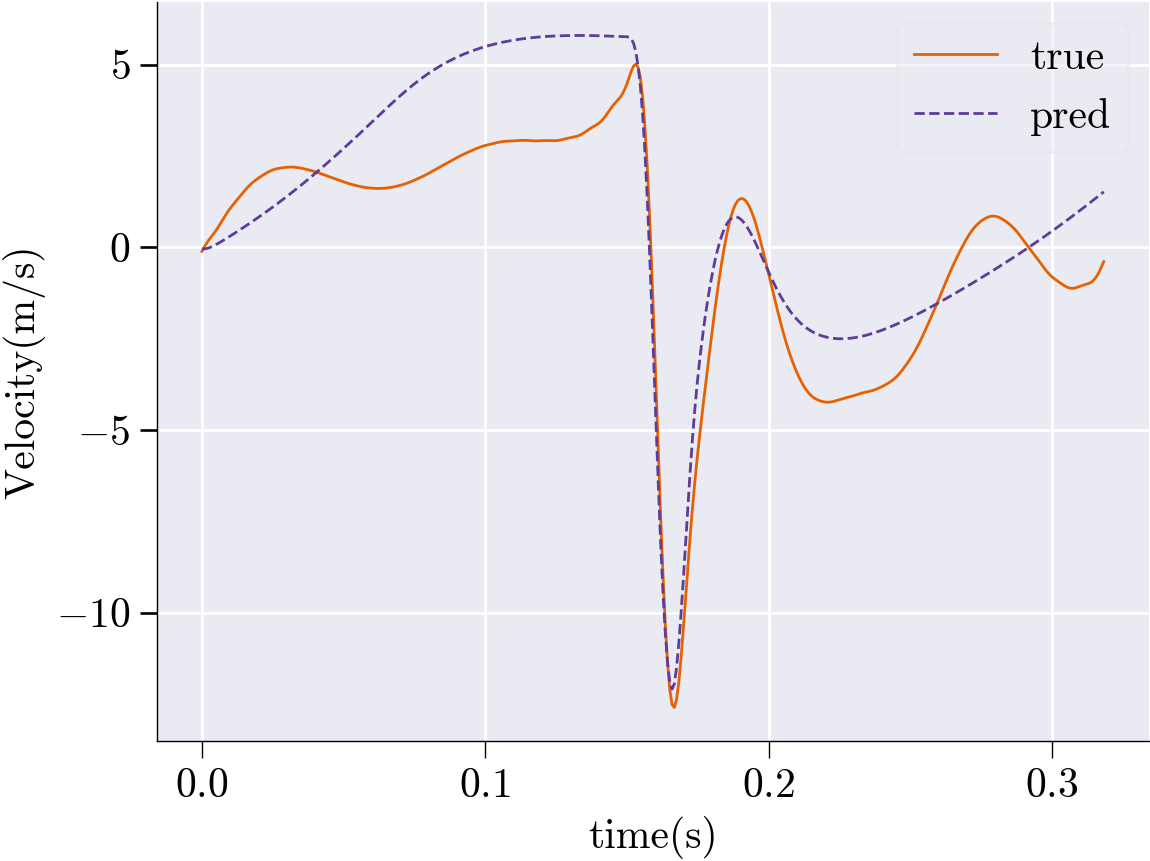

In [18]:
# Single cycle timeline plot
p = 0
x = 75
# Displacement
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x]*disp_norm, label="true")
plt.plot(t, FS_pred[p, :, x]*disp_norm, '--', label="pred")

plt.ylabel("Displacement(m)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

# Velocity
plt.figure(dpi=200)
plt.tight_layout()
plt.plot(t, FS_reshaped[p, :, x+nx]*vel_norm, label="true")
plt.plot(t, FS_pred[p, :, x+nx]*vel_norm, '--', label="pred")

plt.ylabel("Velocity(m/s)")
plt.xlabel("time(s)")
plt.legend()
plt.show()

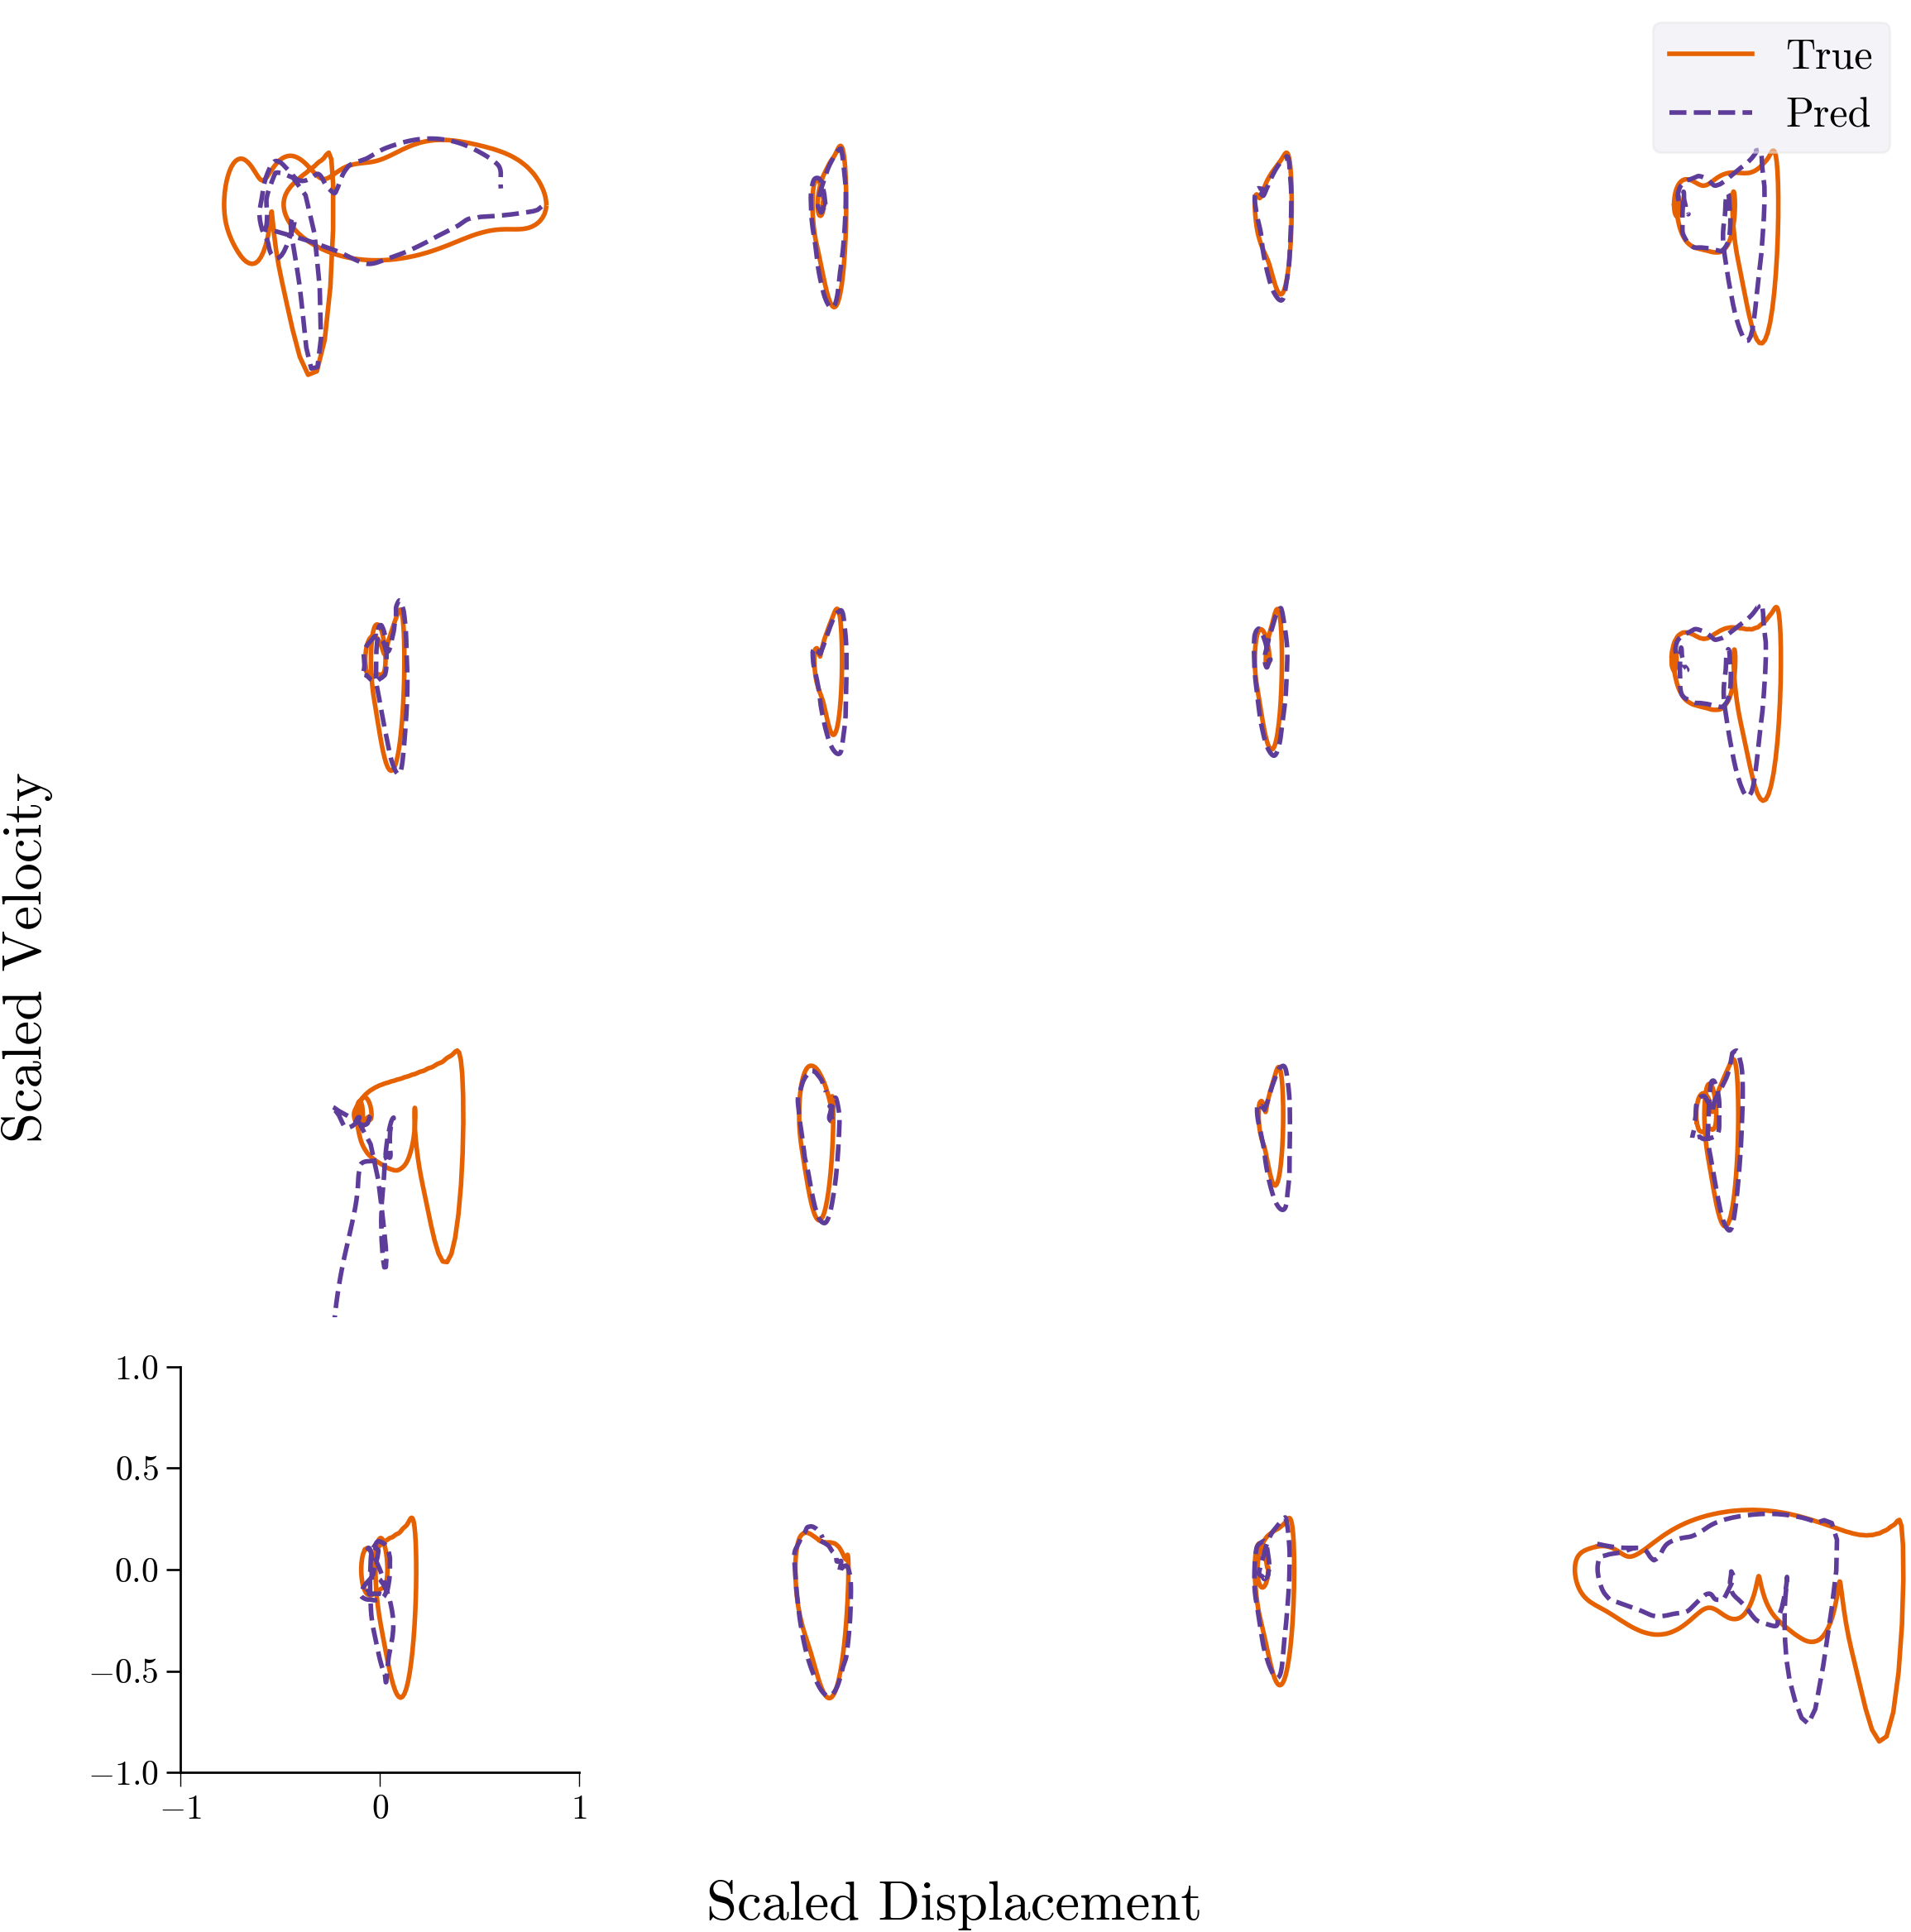

In [25]:
# 4x4 phase plane plots
fig, axes = plt.subplots(4, 4, figsize=(12, 12), dpi=200)
ind = np.linspace(0, 15, 16, dtype=np.int32)
x = 75

it = 0
for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped[ind[it], :, x], FS_reshaped[ind[it], :, x+nx], linewidth = 2, label='True')
        line2, = ax.plot(FS_pred[ind[it], :, x], FS_pred[ind[it], :, x+nx], '--', linewidth = 2, label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_facecolor('none')

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 3 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 3:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()

## Longer Predictions

In [ ]:
num_cycles = 12
model.problem.nodes[4].nsteps = nt*num_cycles
model.problem.eval()

In [ ]:
idx = [0,1,2,3]
test_data_long = {'X': torch.tensor(RS_test[idx], dtype=torch.float32).repeat(1, num_cycles, 1),
                  'x0': torch.tensor(RS_test[idx, 0:1], dtype=torch.float32),
                  'U': torch.tensor(ft_test[idx], dtype=torch.float32).repeat(1, num_cycles, 1),
                  't': torch.tensor(t[:, np.newaxis], dtype=torch.float32).repeat(len(idx), num_cycles, 1)}

In [ ]:
outputs_long = model.problem.step(test_data_long)

In [ ]:
FS_reshaped_long = outputs_long['X'].cpu().detach().numpy()
FS_AE_long = outputs_long['X_hat'][:, :, :].cpu().detach().numpy()
FS_pred_long = outputs_long['x_hat'][:, :-1, :].cpu().detach().numpy()


In [ ]:

print(f"Frob norm for AE is : {np.linalg.norm(FS_AE_long-FS_reshaped_long)/np.linalg.norm(FS_reshaped_long)}")
print(f"Frob norm for NODE is : {np.linalg.norm(FS_pred_long-FS_reshaped_long)/np.linalg.norm(FS_reshaped_long)}")

In [ ]:
# 4x4 phase plane plots
fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=200)
ind = np.linspace(0, 3, 4, dtype=np.int32)
x = 75

it = 0
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped_long[ind[it], :, x], FS_reshaped_long[ind[it], :, x+nx], linewidth = 2, label='True')
        line2, = ax.plot(FS_pred_long[ind[it], :, x], FS_pred_long[ind[it], :, x+nx], '--', linewidth = 2, label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_facecolor('none')

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 1 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 1:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()

In [ ]:
from psd import psd_cutoff, psd_custom

In [ ]:
F_true, Pxx_true = psd_custom(np.linspace(0, T*num_cycles, nt*num_cycles), FS_reshaped_long[0, :, 75])  
F_pred, Pxx_pred = psd_custom(np.linspace(0, T*num_cycles, nt*num_cycles), FS_pred_long[0, :, 75])  

In [ ]:
lim = 300
plt.figure(dpi=200)
plt.plot(F_true[:lim], Pxx_true[:lim], label='true')
plt.plot(F_pred[:lim], Pxx_pred[:lim], '--', label='pred')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.legend()
plt.show()

In [ ]:
plt.figure(dpi=200)
plt.plot(F_true, Pxx_true, label='true')
plt.plot(F_pred, Pxx_pred, '--', label='pred')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.legend()
plt.show()

## Attractor study

In [ ]:
del outputs_long

In [ ]:
def sample_circle_center(n_points=200, radius=0.2, center=(0.0, 0.0), seed=None):
    rng = np.random.default_rng(seed)
    r = radius * np.sqrt(rng.random(n_points))
    theta = 2 * np.pi * rng.random(n_points)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    return np.column_stack((x, y))

def sample_near_edges(n_points=200, band=0.1, square_min=-1.0, square_max=1.0,
                      avoid_circle_radius=0.2, avoid_circle_center=(0.0, 0.0), seed=None):
    rng = np.random.default_rng(seed)
    pts = np.empty((n_points, 2), dtype=float)
    i = 0
    while i < n_points:
        if rng.random() < 0.5:
            x = rng.uniform(square_min, square_max)
            y_edge = rng.choice([square_max, square_min])
            y = y_edge - np.sign(y_edge) * rng.uniform(0.0, band)
        else:
            y = rng.uniform(square_min, square_max)
            x_edge = rng.choice([square_max, square_min])
            x = x_edge - np.sign(x_edge) * rng.uniform(0.0, band)

        dx = x - avoid_circle_center[0]
        dy = y - avoid_circle_center[1]
        if dx*dx + dy*dy >= avoid_circle_radius*avoid_circle_radius:
            pts[i, 0] = x
            pts[i, 1] = y
            i += 1
    return pts

In [ ]:
inner = sample_circle_center(10, radius=0.2, center=(0.0, 0.0), seed=42)
edge  = sample_near_edges(10, band=0.1, avoid_circle_radius=0.2, seed=7)

In [ ]:
x0 = np.vstack([inner, edge])
x0 = np.expand_dims(x0, axis=1)
x0 = np.repeat(x0, sensor_placement.shape[0], axis=-1)

In [ ]:
idx = [0]
test_data_att = {'X': torch.tensor(RS_test[idx], dtype=torch.float32).repeat(1, num_cycles, 1),
                  'x0': torch.tensor(x0, dtype=torch.float32),
                  'U': torch.tensor(ft_test[idx], dtype=torch.float32).repeat(x0.shape[0], num_cycles, 1),
                  't': torch.tensor(t[:, np.newaxis], dtype=torch.float32).repeat(x0.shape[0], num_cycles, 1)}

outputs_att = model.problem.step(test_data_att)
FS_reshaped_att = outputs_att['X'].cpu().detach().numpy()
FS_AE_att = outputs_att['X_hat'][:, :, :].cpu().detach().numpy()
FS_pred_att = outputs_att['x_hat'][:, :-1, :].cpu().detach().numpy()

In [ ]:
att_err = []
for i in range(20):
    att_err.append(np.linalg.norm(FS_pred_att[i, -nt:] - FS_reshaped_att[0, -nt:])/np.linalg.norm(FS_reshaped_att[0, -nt:]))
    # np.linalg.norm(FS_AE-FS_reshaped)/np.linalg.norm(FS_reshaped)

In [ ]:
att_err = 1/np.array(att_err)
att_err /= np.max(att_err)

In [ ]:
idx_true = att_err > 0.90

In [ ]:
x = 75
plt.figure(dpi=200)
plt.plot(FS_reshaped_att[idx[0], -400:, x], FS_reshaped_att[idx[0], -400:, x+nx], label = 'True')
for i in range(10):
    plt.plot(FS_pred_att[i, :, x], FS_pred_att[i, :, x+nx], '--', alpha = att_err[i]*0.4, color = "#5e3c99", label = "Inner Pred")
for i in range(10, 20):
    plt.plot(FS_pred_att[i, :, x], FS_pred_att[i, :, x+nx], '--', alpha = att_err[i]*0.4, color = "#fdb863", label = "Outer Pred")

plt.scatter(FS_pred_att[idx_true, 0, x], FS_pred_att[idx_true, 0, x+nx])
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[0], handles[1], handles[15]], [labels[0], labels[1], labels[15]])
plt.xlabel("Scaled Displacement")
plt.ylabel("Scaled Velocity")
plt.show()

In [ ]:
"""
idx = [0,1,2,3]
test_data_att = {'X': torch.tensor(RS_test[idx], dtype=torch.float32).repeat(1, num_cycles, 1),
                  'x0': torch.tensor(np.random.rand(len(idx), 1, sensor_placement.shape[0]*2)/10, dtype=torch.float32),
                  'U': torch.tensor(ft_test[idx], dtype=torch.float32).repeat(1, num_cycles, 1),
                  't': torch.tensor(t[:, np.newaxis], dtype=torch.float32).repeat(len(idx), num_cycles, 1)}

outputs_att = model.problem.step(test_data_att)
FS_reshaped_att = outputs_att['X'].cpu().detach().numpy()
FS_AE_att = outputs_att['X_hat'][:, :, :].cpu().detach().numpy()
FS_pred_att = outputs_att['x_hat'][:, :-1, :].cpu().detach().numpy()
"""


In [ ]:
"""
# 4x4 phase plane plots
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
ind = np.linspace(0, 3, 4, dtype=np.int32)
x = 75

it = 0
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        line1, = ax.plot(FS_reshaped_att[ind[it], :, x], FS_reshaped_att[ind[it], :, x+nx], label='True')
        line2, = ax.plot(FS_pred_att[ind[it], :, x], FS_pred_att[ind[it], :, x+nx], '--', label='Pred')

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        # Remove all ticks and labels
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)

        # Remove spines (borders)
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Only show axis on bottom-left plot
        if i == 1 and j == 0:
            ax.tick_params(labelbottom=True, labelleft=True, bottom=True, left=True)

            # Enable only left and bottom spines
            ax.spines['left'].set_visible(True)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_linewidth(1)
            ax.spines['bottom'].set_linewidth(1)

            # Ensure the other two remain hidden
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        # Add legend only on top-right plot
        if i == 0 and j == 3:
            ax.legend(handles=[line1, line2], loc='upper right', fontsize=18)

        it += 1

fig.supxlabel('Scaled Displacement', fontsize=24)
fig.supylabel('Scaled Velocity', fontsize=24)
plt.tight_layout()
plt.show()
"""